# Experiment (K Means Clustering)

---

Name : Shruti Hore

PRN : 24070126172

---

Algorithm :
1. Initialize centroids
    Randomly select 𝑘 points from the dataset as initial centroids.

2. Assign clusters
    - For each data point 𝑥, compute the distance to all centroids.
    - Assign 𝑥 to the cluster with the nearest centroid (usually Euclidean distance).

3. Update centroids
- For each cluster, compute the new centroid:
    - Mean of all points assigned to that cluster.

4. Repeat
    - Repeat steps 2 and 3 until:
        
        - Centroids do not change significantly,    
        - Maximum number of iterations is reached.

sample, num of cluster, criteria, attempts

In [1]:
import numpy as np 
import cv2
import matplotlib.pyplot as plt

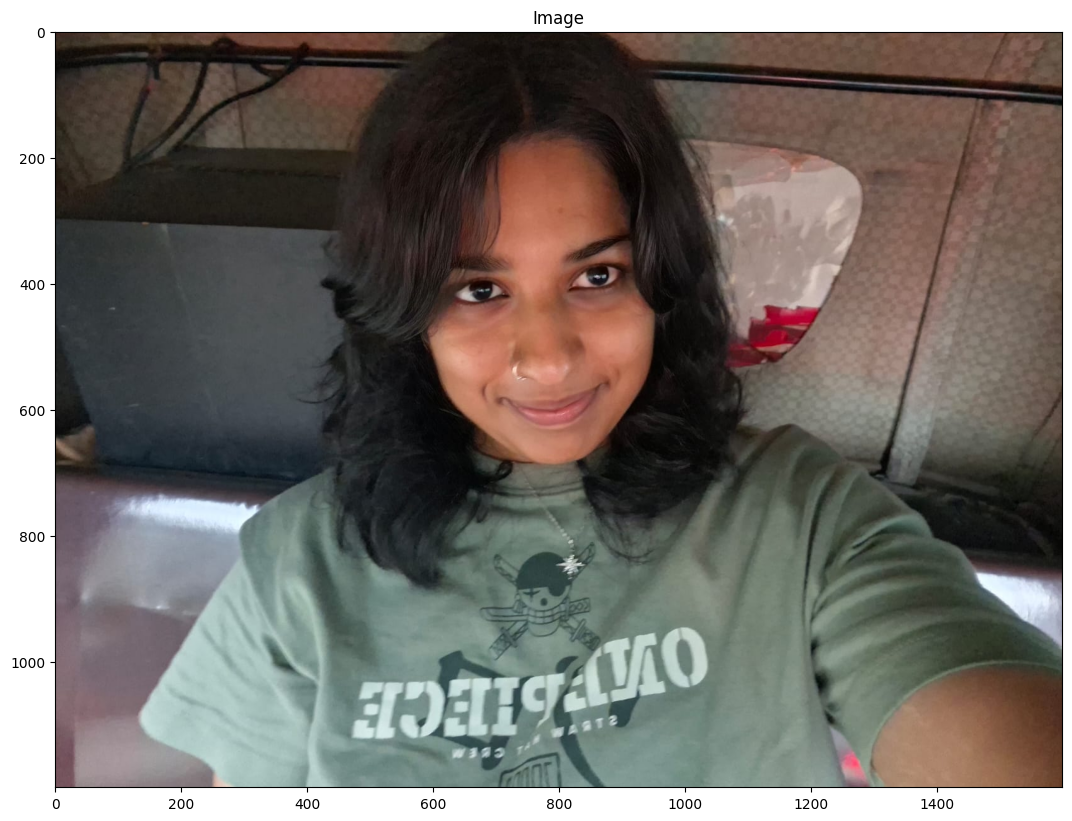

In [2]:
img = cv2.imread("image.jpeg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(13,10))
plt.title("Image")
plt.imshow(img)

In [3]:
print("Shape of image :", img.shape)

Shape of image : (1200, 1600, 3)


In [4]:
# Reshape image (H x W x 3 → N x 3)
vec = img.reshape((-1, 3))
print("Shape of vectorised image ", vec.shape)

Shape of vectorised image  (1920000, 3)


In [5]:
vec = np.float32(vec)
vec

array([[ 69.,  44.,  39.],
       [ 67.,  42.,  37.],
       [ 67.,  42.,  37.],
       ...,
       [103.,  62.,  40.],
       [104.,  63.,  41.],
       [103.,  62.,  40.]], shape=(1920000, 3), dtype=float32)

In [6]:
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

In [7]:
K = 3
attempts=10
ret,label,center=cv2.kmeans(vec,
                            K,
                            None,
                            criteria,
                            attempts,
                            cv2.KMEANS_PP_CENTERS)

In [8]:
center = np.uint8(center)
center

array([[154, 154, 147],
       [ 39,  36,  33],
       [107,  94,  85]], dtype=uint8)

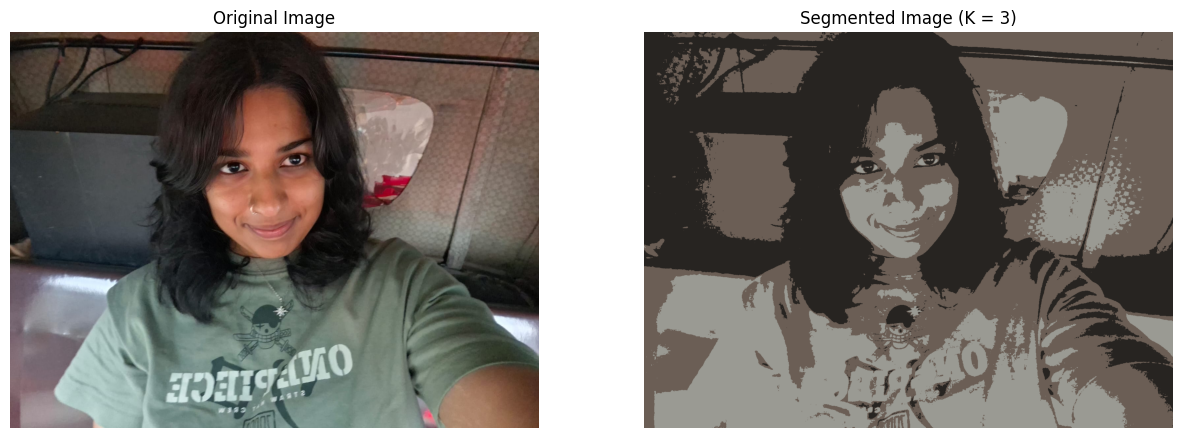

In [9]:
res = center[label.flatten()]
result_image = res.reshape((img.shape))
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(result_image)
plt.title(f"Segmented Image (K = {K})")
plt.axis('off')

plt.show()

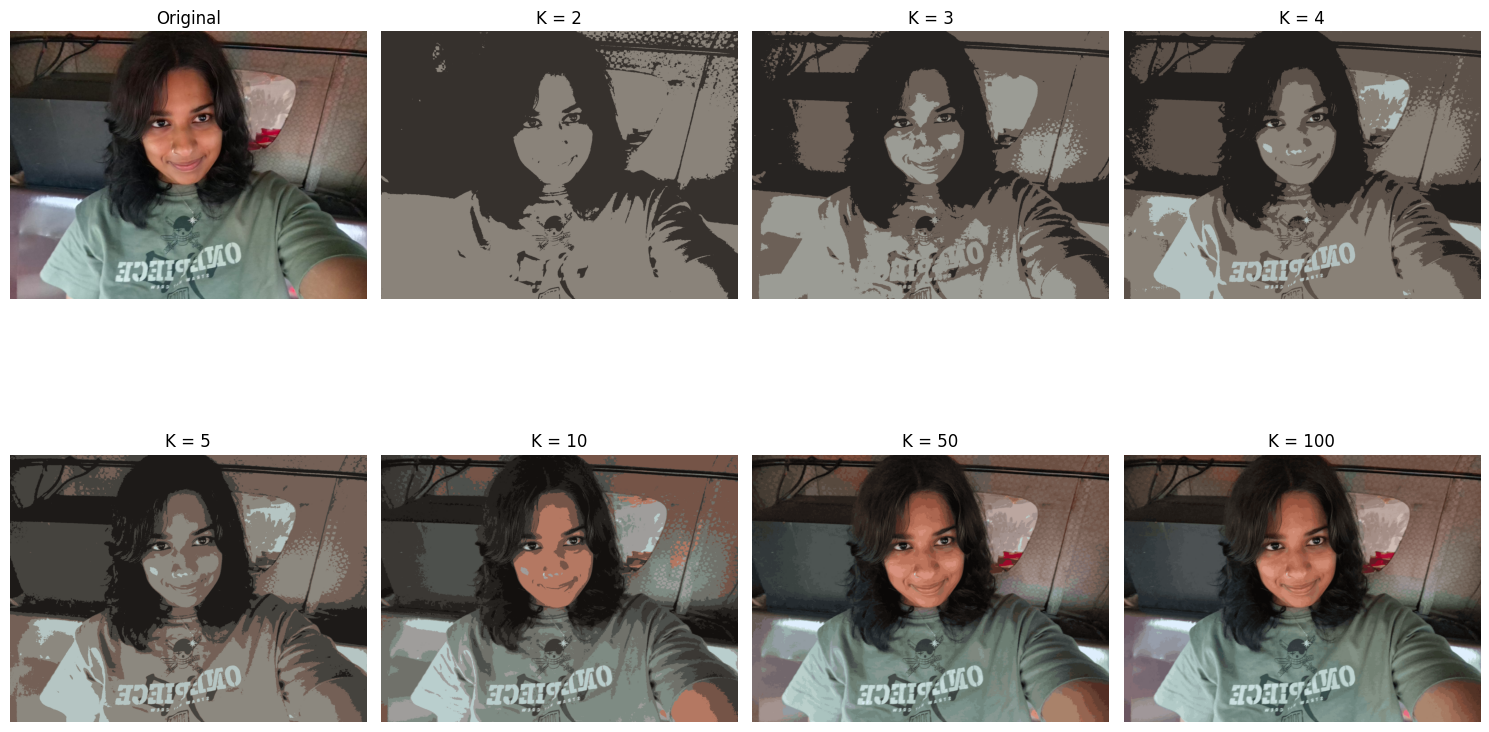

In [ ]:
K_values = [2, 3, 4, 5, 10, 50, 100]

plt.figure(figsize=(15,10))

rows, cols = 2, 4

# Original Image
plt.subplot(rows, cols, 1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

for i, K in enumerate(K_values):
    
    ret, label, center = cv2.kmeans(vec, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    
    center = np.uint8(center)
    res = center[label.flatten()]
    result_image = res.reshape(img.shape)
    
    plt.subplot(rows, cols, i+2)  
    plt.imshow(result_image)
    plt.title(f"K = {K}")
    plt.axis('off')

plt.tight_layout()
plt.show()